# Лабораторная работа 1, часть 2. Transfer Learning
**Задача:** классификация пород кошек и собак (Oxford-IIIT Pet, 37 классов) с помощью предобученной сети **MobileNetV2**.

Две стратегии:
1. **Feature Extraction:** веса базовой сети заморожены, обучается только новый выходной слой.
2. **Fine-tuning:** размораживаются верхние блоки базовой сети и дообучаются с маленьким learning rate.

In [1]:
import os, time, json, copy, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

try:  # на macOS с Python с python.org не всегда подхватываются SSL-сертификаты
    import certifi; os.environ.setdefault('SSL_CERT_FILE', certifi.where())
except ImportError:
    pass

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Устройство: GPU (CUDA в Colab), Apple Silicon (MPS) или CPU
device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device, '| torch', torch.__version__)

Device: mps | torch 2.14.0


## 1. Датасет Oxford-IIIT Pet
Около 7 400 фотографий 37 пород (12 пород кошек, 25 пород собак), примерно по 200 фото на класс.
Используем официальное разбиение: `trainval` (3680) делим на train/val в пропорции 90/10, `test` (3669) берём для итоговой оценки.

In [2]:
DATA_DIR = './data'
IMG_SIZE = 224
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]   # нормализация ImageNet

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_train = datasets.OxfordIIITPet(DATA_DIR, split='trainval', transform=train_tf, download=True)
full_val   = datasets.OxfordIIITPet(DATA_DIR, split='trainval', transform=eval_tf,  download=True)
test_set   = datasets.OxfordIIITPet(DATA_DIR, split='test',     transform=eval_tf,  download=True)
class_names = full_train.classes
num_classes = len(class_names)

idx = np.random.RandomState(SEED).permutation(len(full_train))
n_val = int(0.1 * len(idx))
train_set = Subset(full_train, idx[n_val:])
val_set   = Subset(full_val,   idx[:n_val])

BATCH = 32
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=64,    shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=64,    shuffle=False, num_workers=0)

print(f'Классов: {num_classes}')
print(f'Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}')
print(class_names)

Классов: 37
Train: 3312, Val: 368, Test: 3669
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


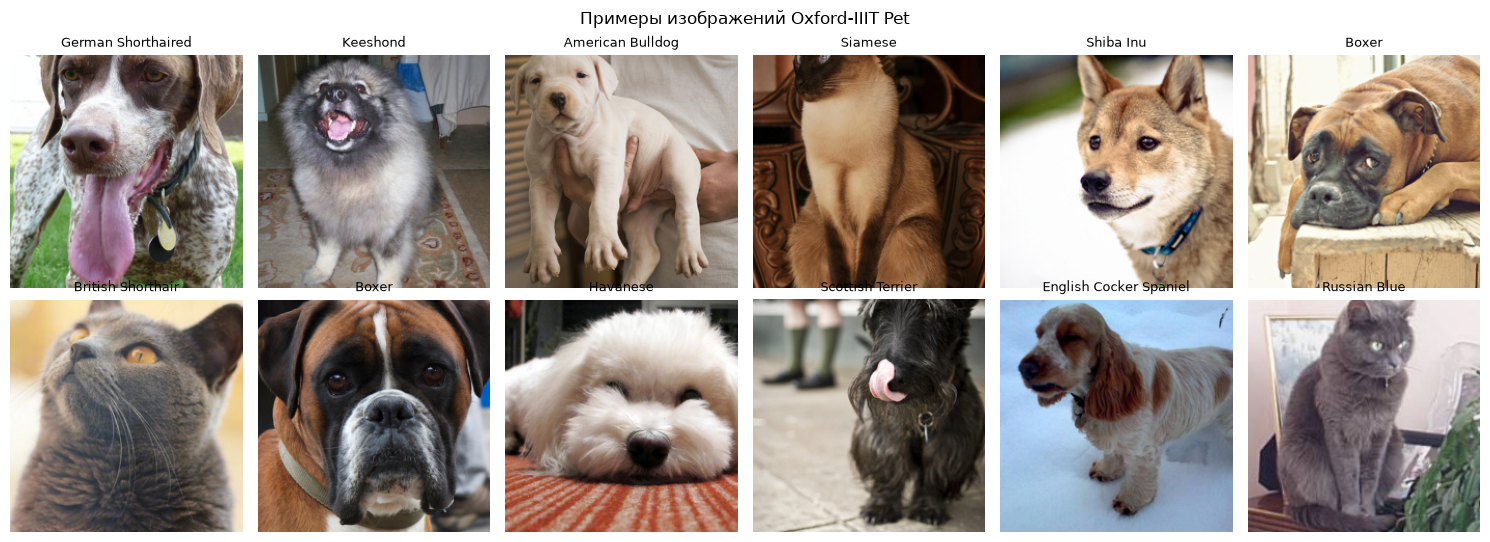

In [3]:
# Примеры изображений из датасета
def denorm(t):
    return (t.permute(1, 2, 0).numpy() * STD + MEAN).clip(0, 1)

fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for ax, i in zip(axes.flat, np.random.RandomState(1).choice(len(test_set), 12, replace=False)):
    img, label = test_set[i]
    ax.imshow(denorm(img)); ax.set_title(class_names[label], fontsize=9); ax.axis('off')
plt.suptitle('Примеры изображений Oxford-IIIT Pet'); plt.tight_layout(); plt.show()

## 2. Выбор архитектуры: MobileNetV2
* **Лёгкая:** 3.5 млн параметров (у ResNet-50 около 25.6 млн, у EfficientNet-B0 около 5.3 млн), поэтому быстро обучается даже без мощной видеокарты (на ноутбуке и в бесплатном Colab).
* **Точная:** на ImageNet top-1 около 72% (веса IMAGENET1K_V2), этого достаточно, чтобы признаки хорошо переносились на новые задачи.
* **Архитектура:** *inverted residual* блоки с *depthwise separable* свёртками и линейным bottleneck. Depthwise-свёртка обрабатывает каждый канал отдельно, pointwise-свёртка 1×1 смешивает каналы. Вычислений примерно в 8–9 раз меньше, чем у обычной свёртки.
* ImageNet содержит много классов кошек и собак, поэтому предобученные признаки хорошо подходят именно под нашу задачу.

In [4]:
def build_model():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V2)
    # Заменяем выходной слой: 1000 классов ImageNet -> 37 пород
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)
    return model.to(device)

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

m = build_model()
print(m.classifier)
print('Блоков в model.features:', len(m.features))
print('Всего параметров: %d' % count_params(m)[0])
del m

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=37, bias=True)
)
Блоков в model.features: 19
Всего параметров: 2271269


In [5]:
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

def fit(model, optimizer, epochs, scheduler=None, tag=''):
    criterion = nn.CrossEntropyLoss()
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc, best_state = 0, None
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta = run_epoch(model, train_loader, criterion, optimizer)
        vl, va = run_epoch(model, val_loader, criterion)
        if scheduler: scheduler.step()
        for k, v in zip(hist, (tl, ta, vl, va)): hist[k].append(v)
        if va > best_acc:
            best_acc, best_state = va, copy.deepcopy(model.state_dict())
        print(f'[{tag}] epoch {ep}/{epochs}  train loss {tl:.3f} acc {ta:.3f} | '
              f'val loss {vl:.3f} acc {va:.3f} | {time.time()-t0:.0f}s')
    model.load_state_dict(best_state)
    return hist

@torch.no_grad()
def predict(model, loader):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        ps.append(model(x.to(device)).argmax(1).cpu()); ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

def metrics(y_true, y_pred):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1':        f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=90, fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel('Predicted label'); ax.set_ylabel('True label'); ax.set_title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

def top_confusions(y_true, y_pred, k=5):
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0)
    flat = np.argsort(cm.ravel())[::-1][:k]
    for f in flat:
        i, j = divmod(f, num_classes)
        print(f'  {class_names[i]:28s} -> {class_names[j]:28s}: {cm[i, j]} ошибок')

## 3. Стратегия 1: Feature Extraction
Замораживаем **все** веса сверточной части (`requires_grad = False`), так что она работает как фиксированный извлекатель признаков (вектор 1280 чисел). Обучаем только новый слой `Linear(1280 → 37)`.

In [6]:
fe_model = build_model()
for p in fe_model.features.parameters():
    p.requires_grad = False

total, trainable = count_params(fe_model)
print(f'Обучаемых параметров: {trainable:,} из {total:,} ({100*trainable/total:.2f}%)')

EPOCHS_FE = 6
opt_fe = torch.optim.Adam(fe_model.classifier.parameters(), lr=1e-3)
t0 = time.time()
hist_fe = fit(fe_model, opt_fe, EPOCHS_FE, tag='FE')
time_fe = time.time() - t0
print(f'Время обучения: {time_fe/60:.1f} мин')

Обучаемых параметров: 47,397 из 2,271,269 (2.09%)


[FE] epoch 1/6  train loss 2.190 acc 0.582 | val loss 1.185 acc 0.837 | 16s


[FE] epoch 2/6  train loss 0.982 acc 0.833 | val loss 0.742 acc 0.867 | 15s


[FE] epoch 3/6  train loss 0.686 acc 0.867 | val loss 0.606 acc 0.867 | 15s


[FE] epoch 4/6  train loss 0.545 acc 0.889 | val loss 0.519 acc 0.878 | 15s


[FE] epoch 5/6  train loss 0.462 acc 0.900 | val loss 0.473 acc 0.864 | 15s


[FE] epoch 6/6  train loss 0.414 acc 0.906 | val loss 0.437 acc 0.875 | 16s
Время обучения: 1.5 мин


In [7]:
y_true, y_pred_fe = predict(fe_model, test_loader)
m_fe = metrics(y_true, y_pred_fe)
print('Feature Extraction, метрики на тестовой выборке:')
for k, v in m_fe.items(): print(f'  {k:10s} = {100*v:.2f}%')
print('\nСамые частые ошибки:'); top_confusions(y_true, y_pred_fe)

Feature Extraction, метрики на тестовой выборке:
  Accuracy   = 85.12%
  Precision  = 85.33%
  Recall     = 85.04%
  F1         = 84.85%

Самые частые ошибки:
  American Pit Bull Terrier    -> Staffordshire Bull Terrier  : 24 ошибок
  Bengal                       -> Egyptian Mau                : 23 ошибок
  Birman                       -> Ragdoll                     : 18 ошибок
  Staffordshire Bull Terrier   -> American Pit Bull Terrier   : 16 ошибок
  British Shorthair            -> Russian Blue                : 16 ошибок


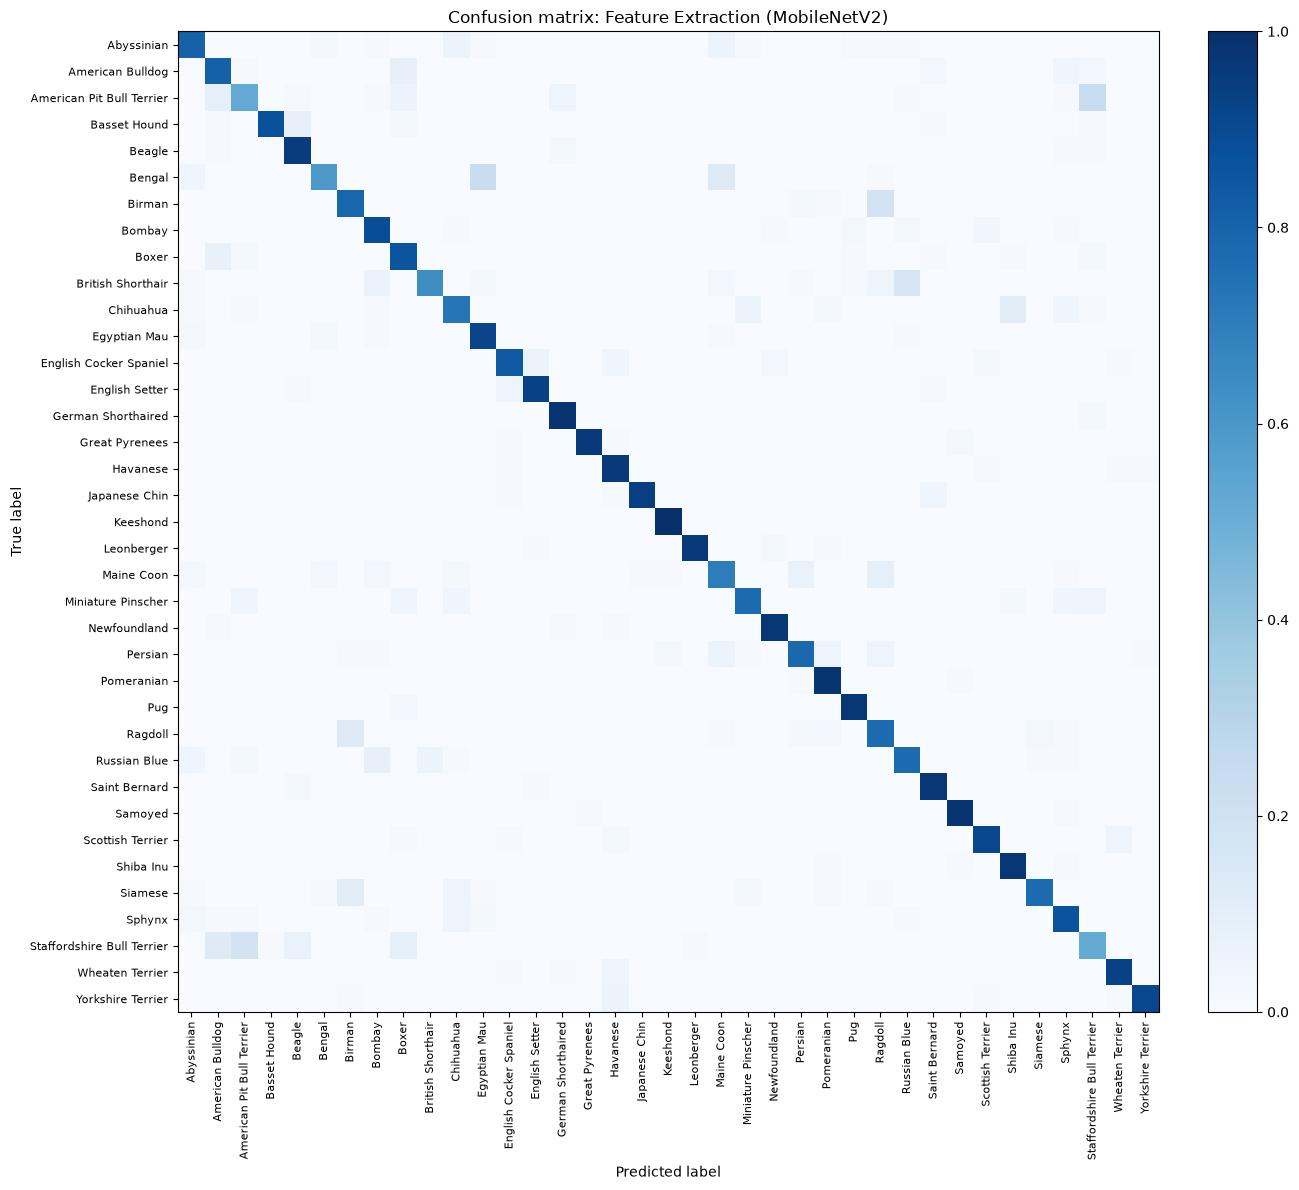

In [8]:
plot_confusion(y_true, y_pred_fe, 'Confusion matrix: Feature Extraction (MobileNetV2)')

## 4. Стратегия 2: Fine-tuning
Берём модель после Feature Extraction (новая «голова» уже обучена, поэтому большие случайные градиенты не испортят предобученные веса). **Размораживаем верхние блоки** `features[14:]` (последние 5 блоков из 19, самые «специфичные» признаки) и дообучаем с **маленьким learning rate**: `1e-4` для базовой сети и `1e-3` для головы, с косинусным затуханием.
Нижние блоки (края, текстуры) остаются замороженными: эти признаки универсальны.

In [9]:
ft_model = copy.deepcopy(fe_model)
UNFREEZE_FROM = 14
for i, block in enumerate(ft_model.features):
    for p in block.parameters():
        p.requires_grad = i >= UNFREEZE_FROM

# BatchNorm в замороженных блоках оставляем в режиме eval, чтобы не сбивать их статистику
def freeze_bn(model):
    for i, block in enumerate(model.features):
        if i < UNFREEZE_FROM:
            for mod in block.modules():
                if isinstance(mod, nn.BatchNorm2d): mod.eval()

total, trainable = count_params(ft_model)
print(f'Обучаемых параметров: {trainable:,} из {total:,} ({100*trainable/total:.2f}%)')

EPOCHS_FT = 6
opt_ft = torch.optim.Adam([
    {'params': [p for p in ft_model.features.parameters() if p.requires_grad], 'lr': 1e-4},
    {'params': ft_model.classifier.parameters(), 'lr': 1e-3},
])
sched_ft = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ft, T_max=EPOCHS_FT)

_orig_train = ft_model.train
def _train(mode=True):
    _orig_train(mode)
    if mode: freeze_bn(ft_model)
    return ft_model
ft_model.train = _train

t0 = time.time()
hist_ft = fit(ft_model, opt_ft, EPOCHS_FT, scheduler=sched_ft, tag='FT')
time_ft = time.time() - t0
print(f'Время обучения: {time_ft/60:.1f} мин')

Обучаемых параметров: 1,728,741 из 2,271,269 (76.11%)


[FT] epoch 1/6  train loss 0.375 acc 0.899 | val loss 0.341 acc 0.872 | 16s


[FT] epoch 2/6  train loss 0.219 acc 0.934 | val loss 0.291 acc 0.886 | 15s


[FT] epoch 3/6  train loss 0.165 acc 0.956 | val loss 0.255 acc 0.918 | 15s


[FT] epoch 4/6  train loss 0.124 acc 0.970 | val loss 0.252 acc 0.891 | 15s


[FT] epoch 5/6  train loss 0.100 acc 0.980 | val loss 0.249 acc 0.913 | 15s


[FT] epoch 6/6  train loss 0.089 acc 0.984 | val loss 0.245 acc 0.910 | 15s
Время обучения: 1.5 мин


In [10]:
_, y_pred_ft = predict(ft_model, test_loader)
m_ft = metrics(y_true, y_pred_ft)
print('Fine-tuning, метрики на тестовой выборке:')
for k, v in m_ft.items(): print(f'  {k:10s} = {100*v:.2f}%')
print('\nСамые частые ошибки:'); top_confusions(y_true, y_pred_ft)

Fine-tuning, метрики на тестовой выборке:
  Accuracy   = 88.01%
  Precision  = 88.16%
  Recall     = 87.91%
  F1         = 87.85%

Самые частые ошибки:
  Staffordshire Bull Terrier   -> American Pit Bull Terrier   : 19 ошибок
  Birman                       -> Ragdoll                     : 18 ошибок
  American Pit Bull Terrier    -> Staffordshire Bull Terrier  : 17 ошибок
  American Pit Bull Terrier    -> American Bulldog            : 15 ошибок
  Staffordshire Bull Terrier   -> American Bulldog            : 13 ошибок


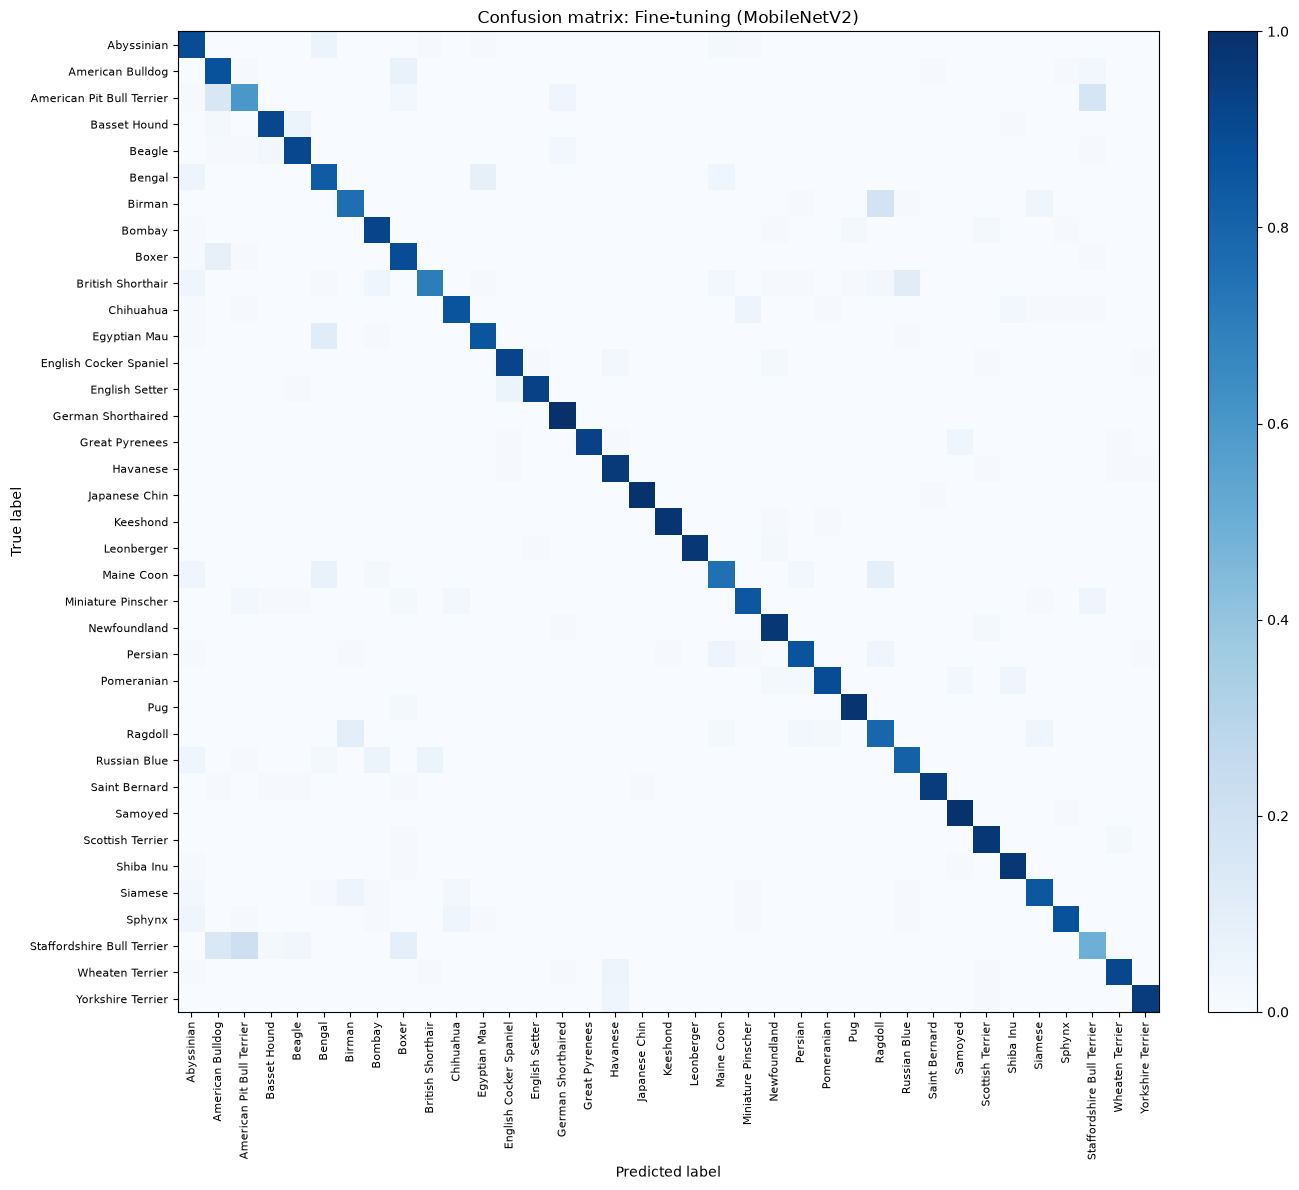

In [11]:
plot_confusion(y_true, y_pred_ft, 'Confusion matrix: Fine-tuning (MobileNetV2)')

## 5. Сравнение стратегий

In [12]:
print(f"{'Метрика':12s} {'Feature Extraction':>20s} {'Fine-tuning':>14s} {'Разница':>10s}")
for k in m_fe:
    print(f"{k:12s} {100*m_fe[k]:19.2f}% {100*m_ft[k]:13.2f}% {100*(m_ft[k]-m_fe[k]):+9.2f}%")
print(f"{'Время, мин':12s} {time_fe/60:20.1f} {time_ft/60:14.1f}")
print(f"{'Эпох':12s} {EPOCHS_FE:20d} {str(EPOCHS_FE) + '+' + str(EPOCHS_FT):>14s}")

# Сохраняем результаты (из них собирается текст отчета)
def top_pairs(y_pred, k=5):
    cm = confusion_matrix(y_true, y_pred); np.fill_diagonal(cm, 0)
    return [[class_names[i], class_names[j], int(cm[i, j])]
            for i, j in (divmod(f, num_classes) for f in np.argsort(cm.ravel())[::-1][:k])]
# Порода кошки или собаки: в Oxford-IIIT Pet породы кошек пишутся с заглавной буквы в именах файлов
is_cat = np.zeros(num_classes, bool)
for path, lab in zip(test_set._images, test_set._labels):
    is_cat[lab] = os.path.basename(path)[0].isupper()
cat_dog_err = lambda yp: int((is_cat[y_true] != is_cat[yp]).sum())
f1_cls = f1_score(y_true, y_pred_ft, average=None)
json.dump({'feature_extraction': m_fe, 'fine_tuning': m_ft,
           'time_fe_min': time_fe/60, 'time_ft_min': time_ft/60,
           'epochs_fe': EPOCHS_FE, 'epochs_ft': EPOCHS_FT,
           'params_total': count_params(fe_model)[0],
           'params_fe': sum(p.numel() for p in fe_model.parameters() if p.requires_grad),
           'params_ft': sum(p.numel() for p in ft_model.parameters() if p.requires_grad),
           'errors_fe': int((y_pred_fe != y_true).sum()), 'errors_ft': int((y_pred_ft != y_true).sum()),
           'n_test': int(len(y_true)),
           'cat_dog_errors_fe': cat_dog_err(y_pred_fe), 'cat_dog_errors_ft': cat_dog_err(y_pred_ft),
           'top_fe': top_pairs(y_pred_fe), 'top_ft': top_pairs(y_pred_ft),
           'worst_ft': [[class_names[i], float(f1_cls[i])] for i in np.argsort(f1_cls)[:3]],
           'best_ft': [[class_names[i], float(f1_cls[i])] for i in np.argsort(f1_cls)[::-1][:3]],
           'hist_fe': hist_fe, 'hist_ft': hist_ft},
          open('results.json', 'w'), indent=2, ensure_ascii=False)
print('Ошибок кошка<->собака: FE', cat_dog_err(y_pred_fe), '| FT', cat_dog_err(y_pred_ft))

Метрика        Feature Extraction    Fine-tuning    Разница
Accuracy                   85.12%         88.01%     +2.89%
Precision                  85.33%         88.16%     +2.83%
Recall                     85.04%         87.91%     +2.87%
F1                         84.85%         87.85%     +3.00%
Время, мин                    1.5            1.5
Эпох                            6            6+6
Ошибок кошка<->собака: FE 72 | FT 37


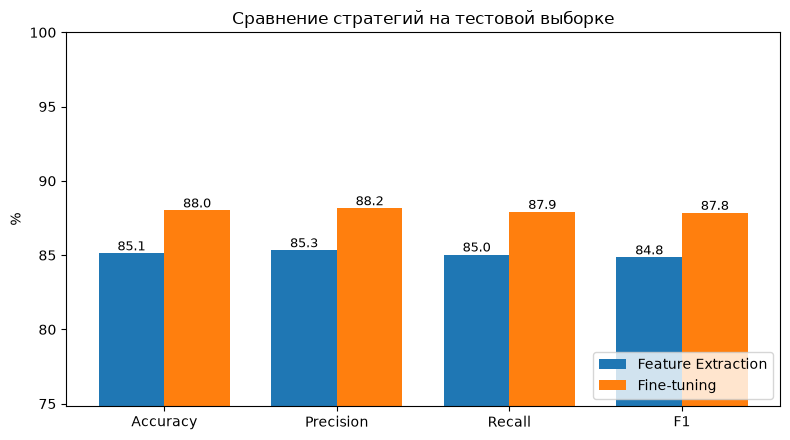

In [13]:
# Метрики обеих стратегий на одном графике
names = list(m_fe)
x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - w/2, [100*m_fe[k] for k in names], w, label='Feature Extraction')
b2 = ax.bar(x + w/2, [100*m_ft[k] for k in names], w, label='Fine-tuning')
ax.bar_label(b1, fmt='%.1f', fontsize=9); ax.bar_label(b2, fmt='%.1f', fontsize=9)
ax.set_xticks(x, names); ax.set_ylabel('%')
lo = min(min(m_fe.values()), min(m_ft.values())) * 100
ax.set_ylim(max(0, lo - 10), 100)
ax.set_title('Сравнение стратегий на тестовой выборке'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

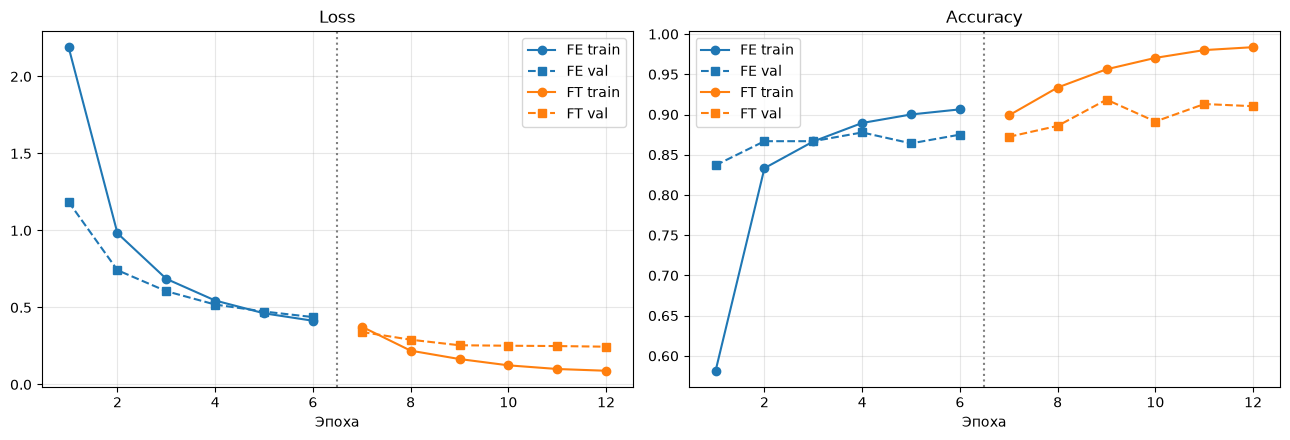

In [14]:
# Кривые обучения: Fine-tuning продолжает Feature Extraction
ep_fe = np.arange(1, EPOCHS_FE + 1)
ep_ft = np.arange(EPOCHS_FE + 1, EPOCHS_FE + EPOCHS_FT + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, key, title in [(axes[0], 'loss', 'Loss'), (axes[1], 'acc', 'Accuracy')]:
    ax.plot(ep_fe, hist_fe['train_' + key], 'o-', c='tab:blue',   label='FE train')
    ax.plot(ep_fe, hist_fe['val_' + key],   's--', c='tab:blue',  label='FE val')
    ax.plot(ep_ft, hist_ft['train_' + key], 'o-', c='tab:orange', label='FT train')
    ax.plot(ep_ft, hist_ft['val_' + key],   's--', c='tab:orange',label='FT val')
    ax.axvline(EPOCHS_FE + 0.5, c='gray', ls=':'); ax.set_xlabel('Эпоха')
    ax.set_title(title); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

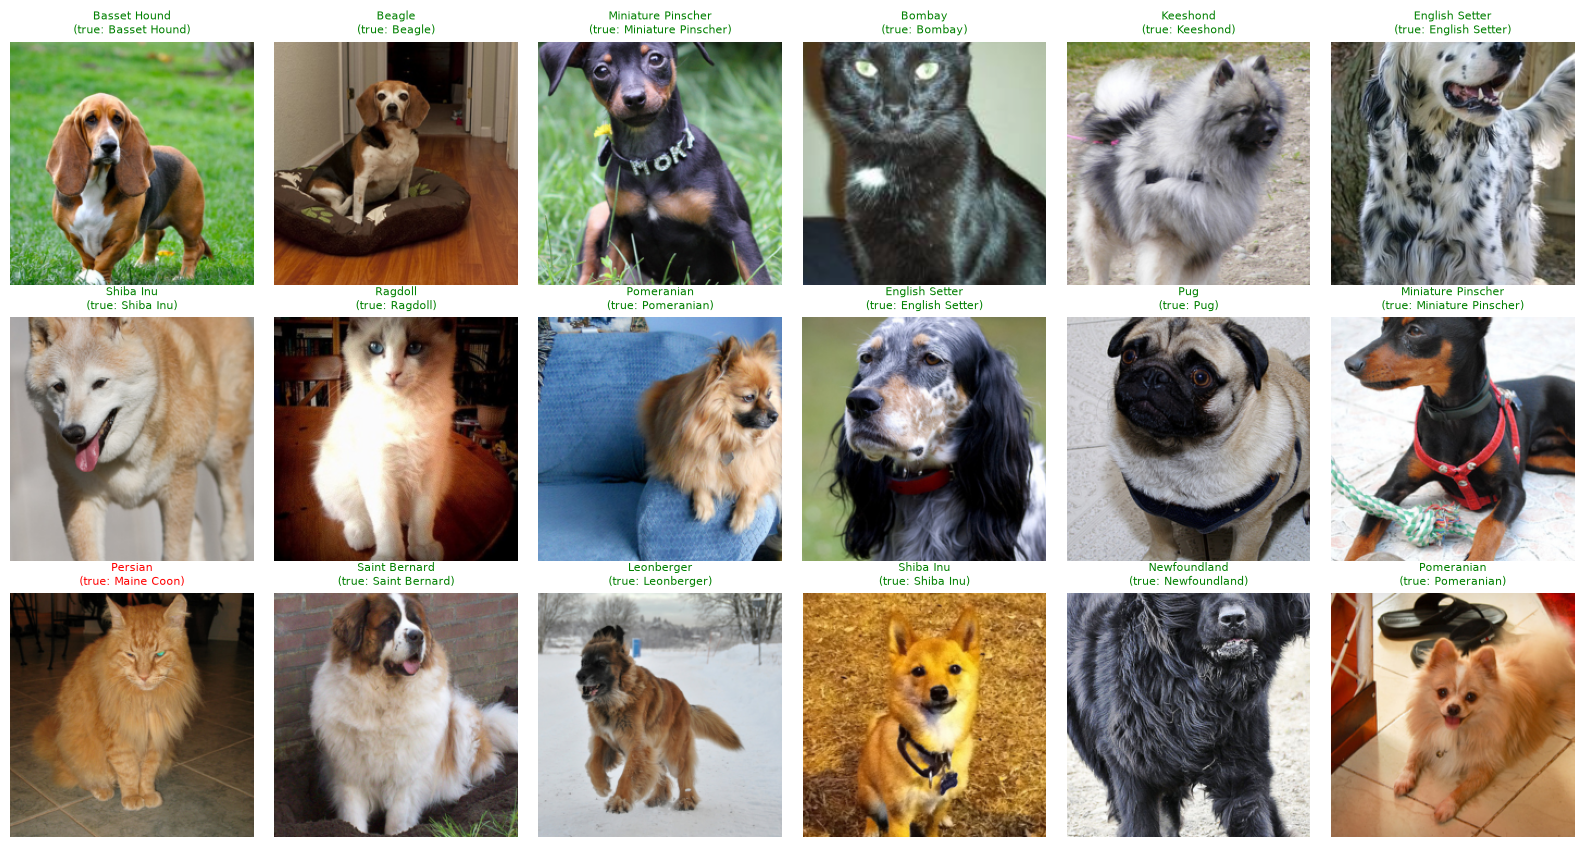

In [15]:
# Примеры предсказаний модели после Fine-tuning (зелёный: верно, красный: ошибка)
fig, axes = plt.subplots(3, 6, figsize=(16, 8.5))
for ax, i in zip(axes.flat, np.random.RandomState(7).choice(len(test_set), 18, replace=False)):
    img, label = test_set[i]
    ax.imshow(denorm(img)); ax.axis('off')
    p = y_pred_ft[i]
    ax.set_title(f'{class_names[p]}\n(true: {class_names[label]})', fontsize=8,
                 color='green' if p == label else 'red')
plt.tight_layout(); plt.show()

In [16]:
print(classification_report(y_true, y_pred_ft, target_names=class_names, digits=3))

                            precision    recall  f1-score   support

                Abyssinian      0.731     0.888     0.802        98
          American Bulldog      0.685     0.870     0.767       100
 American Pit Bull Terrier      0.682     0.600     0.638       100
              Basset Hound      0.929     0.910     0.919       100
                    Beagle      0.883     0.910     0.897       100
                    Bengal      0.748     0.830     0.787       100
                    Birman      0.826     0.760     0.792       100
                    Bombay      0.844     0.920     0.880        88
                     Boxer      0.779     0.889     0.830        99
         British Shorthair      0.897     0.700     0.787       100
                 Chihuahua      0.896     0.860     0.878       100
              Egyptian Mau      0.883     0.856     0.869        97
    English Cocker Spaniel      0.920     0.920     0.920       100
            English Setter      0.979     0.930